In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [2]:
df = pd.read_csv("data_analytics_practice.csv")
df.head()

,order_id,date,region,product,channel,units_sold,price,revenue
0,1001,2025-01-01,East,Accessory,Retail,18,136,2448
1,1002,2025-01-02,West,Laptop,Partner,14,1071,14994
2,1003,2025-01-03,North,Smartphone,Online,18,488,8784
3,1004,2025-01-04,East,Tablet,Partner,2,686,1372
4,1005,2025-01-05,East,Laptop,Retail,3,1246,3738


## 🟢 Basic
### Wie hoch ist der Gesamtumsatz?

In [3]:
df["revenue"].sum()

696610

### Welches Produkt wurde am häufigsten verkauft (nach units_sold)?

In [19]:
df.groupby("product")["units_sold"].sum()

product
Accessory     316
Laptop        331
Smartphone    229
Tablet        292
Name: units_sold, dtype: int64

### Welche Region hat den meisten Umsatz generiert?

In [22]:
df.groupby("region")["revenue"].sum().sort_values(ascending=False)

region
West     212642
South    197670
East     196532
North     89766
Name: revenue, dtype: int64

In [20]:
df.groupby("region")["revenue"].sum().idxmax()

'West'

## 🟡 Intermediate
### Wie hoch ist der durchschnittliche Preis pro Produktkategorie?

In [9]:
df.groupby("product")["price"].mean().sort_values(ascending=False)

product
Laptop        1158.030303
Smartphone     634.350000
Tablet         467.555556
Accessory       85.612903
Name: price, dtype: float64

### Welcher Verkaufskanal generiert den meisten Umsatz?

In [10]:
df.groupby("channel")["revenue"].sum().sort_values(ascending=False)

channel
Partner    337612
Online     221640
Retail     137358
Name: revenue, dtype: int64

### In welcher Region wird welches Produkt am meisten verkauft?

In [16]:
df.groupby(["region", "product"])["units_sold"].sum()

region  product   
East    Accessory      95
        Laptop        144
        Tablet         54
North   Accessory      19
        Laptop         37
        Smartphone     50
        Tablet         45
South   Accessory      62
        Laptop         81
        Smartphone     84
        Tablet        109
West    Accessory     140
        Laptop         69
        Smartphone     95
        Tablet         84
Name: units_sold, dtype: int64

In [18]:
grouped = df.groupby(["region", "product"])["units_sold"].sum().reset_index()

# bestes Produkt pro Region finden
result = grouped.loc[grouped.groupby("region")["units_sold"].idxmax()]
print(result)

   region     product  units_sold
1    East      Laptop         144
5   North  Smartphone          50
10  South      Tablet         109
11   West   Accessory         140


## 🔵 Fortgeschritten
### Berechne den Umsatz pro Tag und finde den umsatzstärksten Tag.

In [ ]:
df.groupby("date")["revenue"].sum().sort_values(ascending=False)

date
2025-03-27    24871
2025-03-07    22416
2025-01-17    21641
2025-02-02    21040
2025-03-20    20650
              ...  
2025-03-29      186
2025-01-09      105
2025-04-25      102
2025-01-11       88
2025-04-24       71
Name: revenue, Length: 120, dtype: int64

In [26]:
df.groupby("date")["revenue"].sum().idxmax()

'2025-03-27'


### Gibt es einen Trend über die Zeit (z. B. steigender Umsatz)?

In [27]:
daily_revenue = df.groupby("date")["revenue"].sum()

<Axes: xlabel='date'>

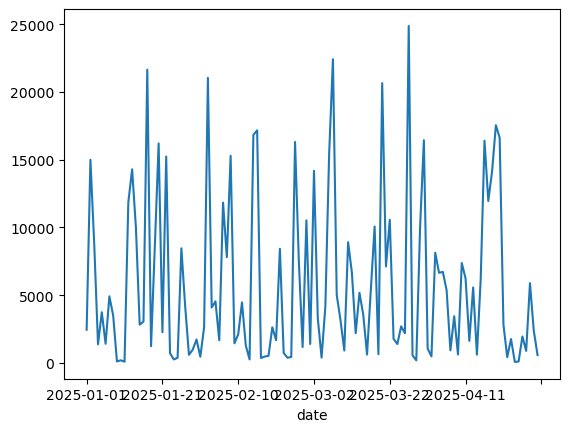

In [28]:
daily_revenue.plot()

<Axes: xlabel='date'>

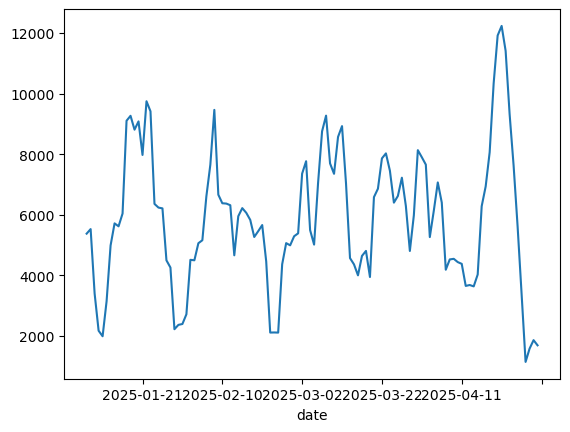

In [29]:
daily_revenue.rolling(window=7).mean().plot()

In [ ]:
# trend mathematisch prüfen

from scipy.stats import linregress

x = range(len(daily_revenue))
y = daily_revenue.values

slope, _, _, _, _ = linregress(x, y)
print(slope) # fallender trend

-1.3981526494895502



### Welche Kombination aus Region + Produkt ist am profitabelsten?

In [34]:
df.groupby(["region", "product"])["revenue"].sum()

region  product   
East    Accessory       8901
        Laptop        162841
        Tablet         24790
North   Accessory        758
        Laptop         42239
        Smartphone     24447
        Tablet         22322
South   Accessory       6633
        Laptop         94792
        Smartphone     50980
        Tablet         45265
West    Accessory      11498
        Laptop         83187
        Smartphone     75199
        Tablet         42758
Name: revenue, dtype: int64

In [35]:
df.groupby(["region", "product"])["revenue"].sum().idxmax()

('East', 'Laptop')

In [36]:
grouped = df.groupby(["region", "product"])["revenue"].sum().reset_index()

best = grouped.loc[grouped["revenue"].idxmax()]
print(best)

region       East
product    Laptop
revenue    162841
Name: 1, dtype: object



### Berechne den durchschnittlichen Umsatz pro Bestellung je Kanal.

In [42]:
df["order_id"].duplicated().any()

False

In [41]:
df.groupby("channel")["revenue"].mean().sort_values(ascending=False)

channel
Partner    7851.441860
Online     5277.142857
Retail     3924.514286
Name: revenue, dtype: float64

## 🔴 Challenge (sehr gut für Interviews)
### Finde Ausreißer bei Preis oder Umsatz.

<Axes: >

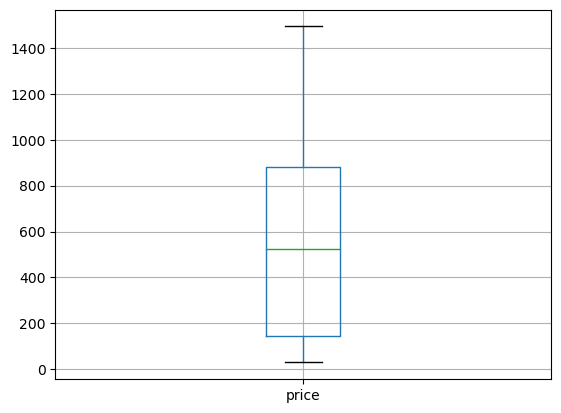

In [47]:
df.boxplot(column="price")

In [48]:
df.groupby("product")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
product,,,,,,,,
Accessory,31.0,85.612903,38.723531,29.0,47.50,93.0,118.50,147.0
Laptop,33.0,1158.030303,212.550653,834.0,1016.00,1195.0,1315.00,1494.0
Smartphone,20.0,634.350000,185.098345,368.0,485.00,616.0,725.25,990.0
Tablet,36.0,467.555556,139.840408,212.0,341.75,489.5,557.00,698.0


In [49]:
# Schritt 1: Quartile berechnen

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

In [51]:
# grenzen definieren

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
# ausreißer finden

outliers_price = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

Empty DataFrame
Columns: [order_id, date, region, product, channel, units_sold, price, revenue, z_price]
Index: []


In [62]:
# identisch für revenue

Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)
IQR = Q3 - Q1

outliers_revenue = df[(df["revenue"] < Q1 - 1.5*IQR) | (df["revenue"] > Q3 + 1.5*IQR)]

print(outliers_revenue)

    order_id        date region product  channel  units_sold  price  revenue  \
16      1017  2025-01-17   West  Laptop  Partner          17   1273    21641   
32      1033  2025-02-02   West  Laptop  Partner          16   1315    21040   
65      1066  2025-03-07  South  Laptop  Partner          16   1401    22416   
78      1079  2025-03-20   East  Laptop  Partner          14   1475    20650   
85      1086  2025-03-27   East  Laptop  Partner          17   1463    24871   

     z_price  
16  1.605424  
32  1.703654  
65  1.904790  
78  2.077860  
85  2.049795  


In [61]:
# z score (einfacher check)

from scipy.stats import zscore

df["z_price"] = zscore(df["price"])

df[df["z_price"].abs() > 3]

,order_id,date,region,product,channel,units_sold,price,revenue,z_price


Es gibt keine Ausreißer im Datensatz.

In [56]:
df.head()

,order_id,date,region,product,channel,units_sold,price,revenue
0,1001,2025-01-01,East,Accessory,Retail,18,136,2448
1,1002,2025-01-02,West,Laptop,Partner,14,1071,14994
2,1003,2025-01-03,North,Smartphone,Online,18,488,8784
3,1004,2025-01-04,East,Tablet,Partner,2,686,1372
4,1005,2025-01-05,East,Laptop,Retail,3,1246,3738



### Baue eine Top-5 Analyse:
  - Top 5 Tage
  - Top 5 Bestellungen nach Umsatz

In [63]:
grouped = df.groupby(["region", "product"])["revenue"].sum().reset_index()
grouped.sort_values("revenue", ascending=False).head(5)

,region,product,revenue
1,East,Laptop,162841
8,South,Laptop,94792
12,West,Laptop,83187
13,West,Smartphone,75199
9,South,Smartphone,50980


In [64]:
grouped = df.groupby("date")["revenue"].sum().reset_index()
grouped.sort_values("revenue", ascending=False).head(5)

,date,revenue
85,2025-03-27,24871
65,2025-03-07,22416
16,2025-01-17,21641
32,2025-02-02,21040
78,2025-03-20,20650



### Wenn du ein Dashboard bauen würdest:
  - Welche 3 KPIs würdest du zeigen?

Ein gutes Dashboard zeigt:

- Performance (Wie viel?)
- Effizienz (Wie gut?)
- Treiber (Warum?)

In [ ]:
# Gesamtumsatz
df["revenue"].sum()

696610

In [66]:
# durchschnittlicher Umsatz pro Bestellung

df["revenue"].mean()

5805.083333333333

In [67]:
# Verkaufsmenge

df["units_sold"].sum()

1168